####Movie / Series Popularity Prediction System
Predict whether a movie or series will have High, Medium or Low popularity on OTT platforms based on features like genre, platform, rating, votes, duration and release year

In [141]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

####Dataset

In [142]:
df = pd.read_csv("/content/ott_movies_ML_NLP_ready.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   content_id         2500 non-null   object 
 1   title              2500 non-null   object 
 2   type               2500 non-null   object 
 3   genre              2500 non-null   object 
 4   platform           2500 non-null   object 
 5   country            2500 non-null   object 
 6   language           2500 non-null   object 
 7   release_year       2500 non-null   int64  
 8   duration_minutes   2500 non-null   int64  
 9   rating             2500 non-null   float64
 10  votes              2500 non-null   int64  
 11  weighted_rating    2500 non-null   float64
 12  engagement_score   2500 non-null   float64
 13  popularity_score   2500 non-null   float64
 14  trending_score     2500 non-null   float64
 15  tags               2500 non-null   object 
 16  combined_features  2500 

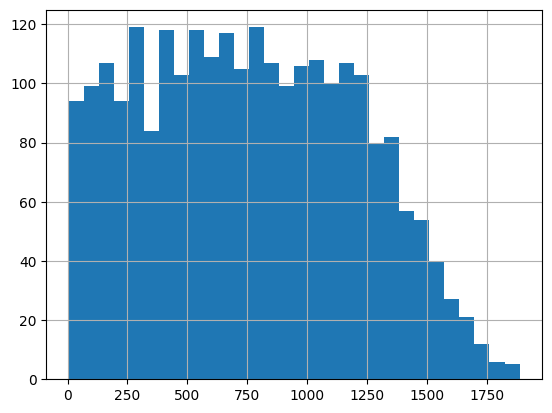

In [143]:
df['popularity_score'].hist(bins = 30)
plt.show()

In [144]:
df['popularity_category'] = pd.qcut(
    df['popularity_score'],
    q=3,
    labels=['Low','Medium','High']
)
df.popularity_category.value_counts()/len(df.popularity_category)*100

,count
popularity_category,
High,33.36
Low,33.32
Medium,33.32


Target Variable is popularity_category

####EDA

In [145]:
correlation = df.corr(numeric_only=True)['popularity_score'].sort_values(ascending=False)
print(correlation)

popularity_score    1.000000
trending_score      0.974638
votes               0.967667
engagement_score    0.431343
weighted_rating     0.257139
rating              0.211502
release_year       -0.012423
duration_minutes   -0.041326
Name: popularity_score, dtype: float64


In [146]:
# Check genre impact on popularity
print(df.groupby('genre')['popularity_score'].mean().sort_values(ascending=False))

# Check platform impact
print(df.groupby('platform')['popularity_score'].mean().sort_values(ascending=False))

# Check type impact — Movie vs Series
print(df.groupby('type')['popularity_score'].mean().sort_values(ascending=False))

# Check language impact
print(df.groupby('language')['popularity_score'].mean().sort_values(ascending=False))

genre
Drama       787.665308
Thriller    785.932010
Sci-Fi      751.957319
Crime       749.870904
Fantasy     745.418038
Name: popularity_score, dtype: float64
platform
Prime Video    780.426082
Netflix        759.613534
Name: popularity_score, dtype: float64
type
Movie     774.216637
Series    748.869157
Name: popularity_score, dtype: float64
language
German     798.239153
Hindi      762.274566
Spanish    756.034701
English    747.149960
Korean     744.299883
Name: popularity_score, dtype: float64


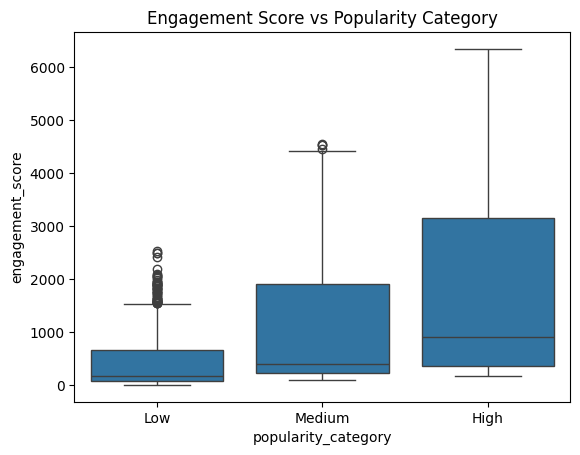

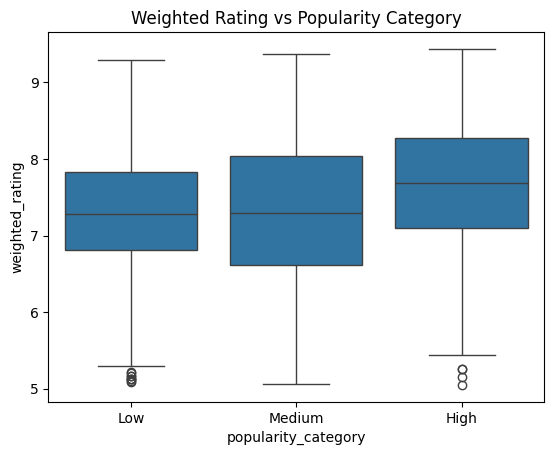

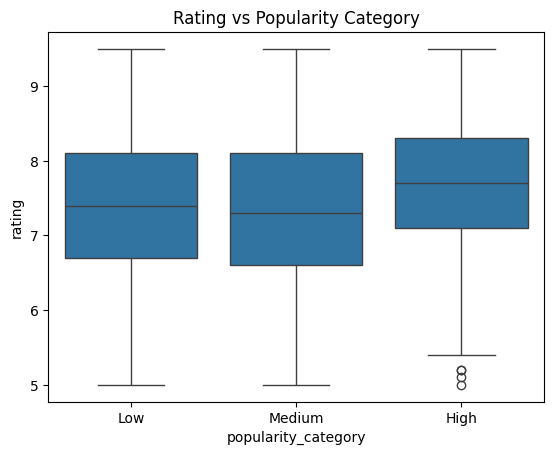

In [147]:
# engagement_score vs popularity_category
sns.boxplot(x='popularity_category', y='engagement_score', data=df)
plt.title("Engagement Score vs Popularity Category")
plt.show()

# weighted_rating vs popularity_category
sns.boxplot(x='popularity_category', y='weighted_rating', data=df)
plt.title("Weighted Rating vs Popularity Category")
plt.show()

# rating vs popularity_category
sns.boxplot(x='popularity_category', y='rating', data=df)
plt.title("Rating vs Popularity Category")
plt.show()

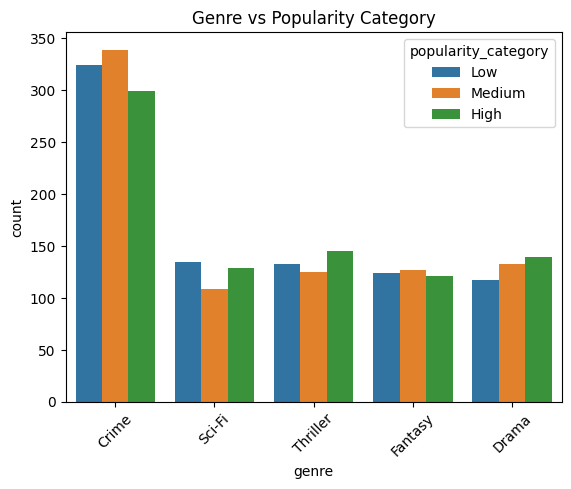

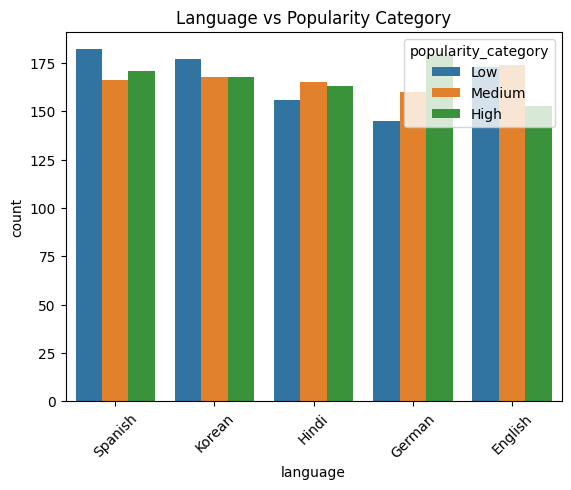

In [148]:
# genre vs popularity_category
sns.countplot(x='genre', hue='popularity_category', data=df)
plt.title("Genre vs Popularity Category")
plt.xticks(rotation=45)
plt.show()

# language vs popularity_category
sns.countplot(x='language', hue='popularity_category', data=df)
plt.title("Language vs Popularity Category")
plt.xticks(rotation=45)
plt.show()

####Feature Engineering

In [149]:
#One Hot Encoding to convert categorical features
df = pd.get_dummies(df, columns=['genre', 'language', 'type','platform','country'], drop_first=True)

In [150]:
df.head()

,content_id,title,release_year,duration_minutes,rating,votes,weighted_rating,engagement_score,popularity_score,trending_score,...,language_Hindi,language_Korean,language_Spanish,type_Series,platform_Prime Video,country_India,country_South Korea,country_Spain,country_UK,country_USA
0,C102437,Sacred Games,2015,80,9.5,199755,9.44,266.34,1885.69,2127.81,...,False,False,True,False,False,False,True,False,False,False
1,C100289,Dark,2016,1310,8.7,197470,8.66,4311.43,1710.09,2048.01,...,False,True,False,True,False,False,False,False,True,False
2,C100620,Ozark,2023,127,8.7,195293,8.66,413.37,1691.24,1993.38,...,True,False,False,False,False,False,True,False,False,False
3,C101349,Mirzapur,2022,151,9.5,176171,9.43,443.36,1661.29,1992.25,...,True,False,False,False,True,False,False,True,False,False
4,C102440,Narcos,2024,1969,9.4,183974,9.34,6037.41,1718.32,1991.03,...,False,False,False,True,False,False,True,False,False,False


In [151]:

le = LabelEncoder()
# Encode target variable
df['popularity_category_encoded'] = le.fit_transform(df['popularity_category'])
print(df['popularity_category_encoded'].value_counts())

popularity_category_encoded
0    834
2    833
1    833
Name: count, dtype: int64


In [152]:
df.shape

(2500, 31)

####Spliting Data into Dependent and Independent variable

In [153]:
# Drop unnecessary columns
drop_cols = ['content_id', 'title', 'tags', 'combined_features',
             'description', 'poster_url', 'popularity_score',
             'trending_score', 'votes', 'popularity_category','engagement_score', 'weighted_rating', 'popularity_category_encoded']

# Features and target
X = df.drop(columns=drop_cols)
y = df['popularity_category']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures used:", X.columns.tolist())

X shape: (2500, 18)
y shape: (2500,)

Features used: ['release_year', 'duration_minutes', 'rating', 'genre_Drama', 'genre_Fantasy', 'genre_Sci-Fi', 'genre_Thriller', 'language_German', 'language_Hindi', 'language_Korean', 'language_Spanish', 'type_Series', 'platform_Prime Video', 'country_India', 'country_South Korea', 'country_Spain', 'country_UK', 'country_USA']


In [154]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)
X_train.shape,X_test.shape

((2000, 18), (500, 18))

In [155]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   release_year          2500 non-null   int64  
 1   duration_minutes      2500 non-null   int64  
 2   rating                2500 non-null   float64
 3   genre_Drama           2500 non-null   bool   
 4   genre_Fantasy         2500 non-null   bool   
 5   genre_Sci-Fi          2500 non-null   bool   
 6   genre_Thriller        2500 non-null   bool   
 7   language_German       2500 non-null   bool   
 8   language_Hindi        2500 non-null   bool   
 9   language_Korean       2500 non-null   bool   
 10  language_Spanish      2500 non-null   bool   
 11  type_Series           2500 non-null   bool   
 12  platform_Prime Video  2500 non-null   bool   
 13  country_India         2500 non-null   bool   
 14  country_South Korea   2500 non-null   bool   
 15  country_Spain        

####Feature Scaling

In [156]:
sc = StandardScaler()

In [157]:
# Check all object columns in X
print(X.select_dtypes(include='object').columns.tolist())

[]


In [158]:
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

###KNN

In [159]:
#KNN Classifier implementation
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
knn_model = KNeighborsClassifier(n_neighbors = 5)
knn_model.fit(X_train_scaled, y_train)
y_pred_kn = knn_model.predict(X_test_scaled)
accuracy_score(y_test, y_pred_kn)*100

31.6

####Decision Tree

In [160]:
#Decision tree Classifier implementation
from sklearn.tree import DecisionTreeClassifier
M2 = DecisionTreeClassifier()
M2.fit(X_train_scaled, y_train)
y_pred_dt = M2.predict(X_test_scaled)
accuracy_score(y_test, y_pred_dt)*100

35.0

In [161]:
print("Classification Report:")
print(classification_report(y_test, y_pred_dt,
      target_names=['High', 'Low', 'Medium']))

Classification Report:
              precision    recall  f1-score   support

        High       0.37      0.33      0.35       167
         Low       0.33      0.33      0.33       167
      Medium       0.35      0.39      0.37       166

    accuracy                           0.35       500
   macro avg       0.35      0.35      0.35       500
weighted avg       0.35      0.35      0.35       500



In [162]:
# Train accuracy vs Test accuracy
train_acc = M2.score(X_train_scaled, y_train)
test_acc = M2.score(X_test_scaled, y_test)

print(f"Train Accuracy: {train_acc}")
print(f"Test Accuracy: {test_acc}")

Train Accuracy: 1.0
Test Accuracy: 0.35


In [163]:
print(X.columns.tolist())

['release_year', 'duration_minutes', 'rating', 'genre_Drama', 'genre_Fantasy', 'genre_Sci-Fi', 'genre_Thriller', 'language_German', 'language_Hindi', 'language_Korean', 'language_Spanish', 'type_Series', 'platform_Prime Video', 'country_India', 'country_South Korea', 'country_Spain', 'country_UK', 'country_USA']


###Random Forest

In [164]:
#Random Forest Classifier implementation
from sklearn.ensemble import RandomForestClassifier
M3 = RandomForestClassifier(n_estimators=100)
M3.fit(X_train_scaled, y_train)
y_pred_rf = M3.predict(X_test_scaled)
accuracy_score(y_test, y_pred_rf)*100

38.4

####Logistic Regression

In [165]:
#Logisctic regression Classifier implementation
from sklearn.linear_model import LogisticRegression
M6 = LogisticRegression()
M6.fit(X_train_scaled, y_train)
y_pred_lr = M6.predict(X_test_scaled)
accuracy_score(y_test, y_pred_lr)*100

35.4

####SVM

In [166]:
#SVM Classifier implementation
from sklearn.svm import SVC
M5 = SVC()
M5.fit(X_train_scaled, y_train)
y_pred_svm = M5.predict(X_test_scaled)
accuracy_score(y_test, y_pred_svm)*100

35.0

####Hyperparameter Tunning on best performing model

In [167]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_weighted',
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

# Evaluate best model
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)

print("\nBest Model Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best)}")
print(f"F1 Score: {f1_score(y_test, y_pred_best, average='weighted')}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits


KeyboardInterrupt: 

####Final Report - OTT Populartiy predictions

###Model Comparision Visualization

/tmp/ipykernel_1930/3381363172.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=final_results, ax=axes[0], palette='Blues_d')
/tmp/ipykernel_1930/3381363172.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_1930/3381363172.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='F1 Score', data=final_results, ax=axes[1], palette='Greens_d')
/tmp/ipykernel_1930/3381363172.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_

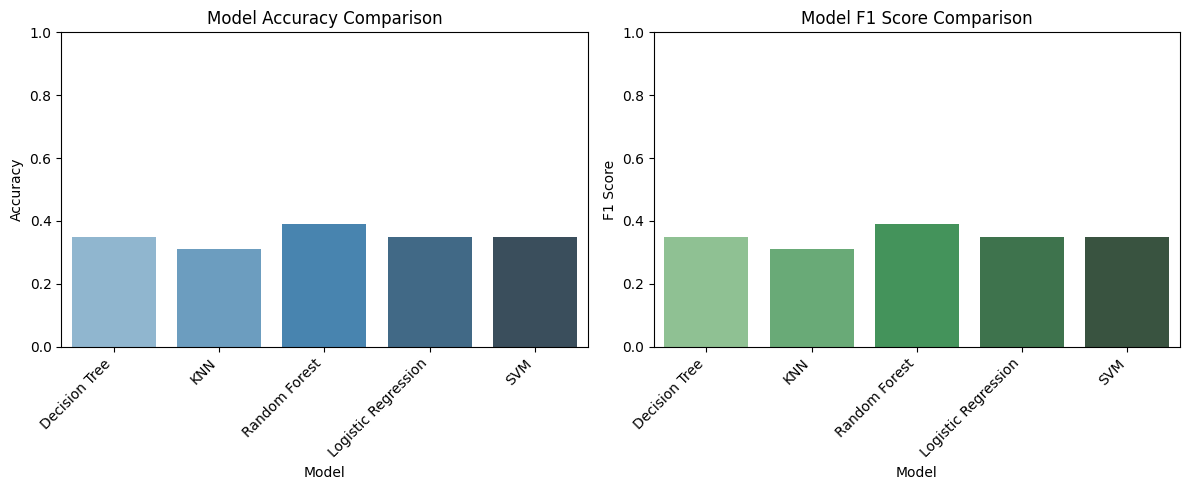

In [168]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create final results dataframe with all models
final_results = pd.DataFrame({
    'Model': ['Decision Tree', 'KNN', 'Random Forest',
              'Logistic Regression', 'SVM'],
    'Accuracy': [0.35, 0.31, 0.39, 0.35, 0.35],
    'F1 Score': [0.35, 0.31, 0.39, 0.35, 0.35]
})

# Bar plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x='Model', y='Accuracy', data=final_results, ax=axes[0], palette='Blues_d')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_ylim(0, 1)

sns.barplot(x='Model', y='F1 Score', data=final_results, ax=axes[1], palette='Greens_d')
axes[1].set_title('Model F1 Score Comparison')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

###Feature Importance Visualization

/tmp/ipykernel_1930/1599936501.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='Oranges_d')


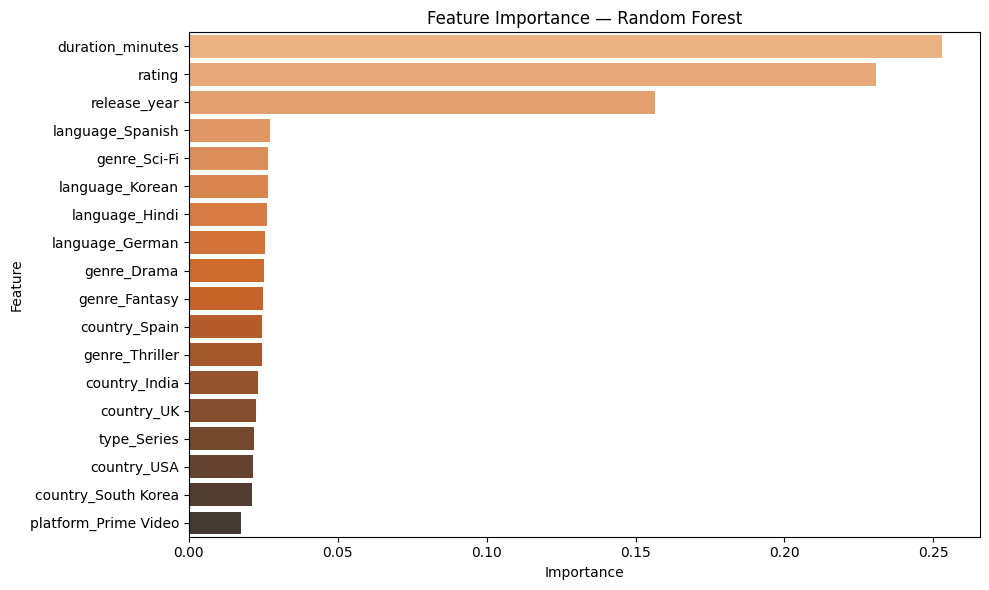

In [169]:
# Feature importance from Random Forest
importance_df = pd.DataFrame({
    'Feature': X.columns.tolist(),
    'Importance': M3.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='Oranges_d')
plt.title('Feature Importance — Random Forest')
plt.tight_layout()
plt.show()

####Confusion Matrix of best Model

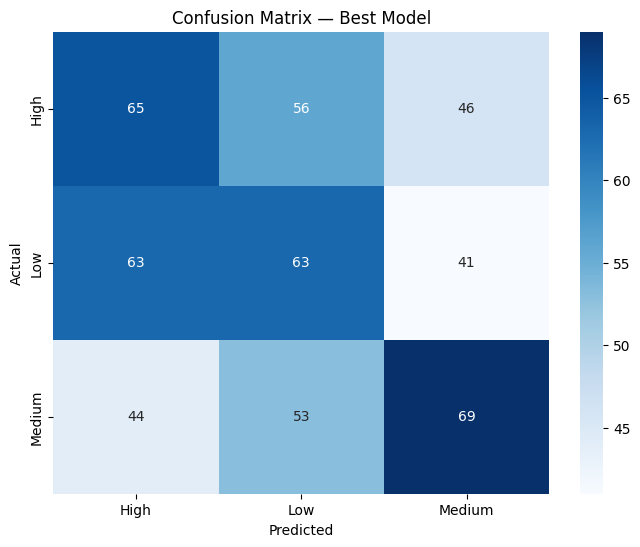

In [170]:
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['High', 'Low', 'Medium'],
            yticklabels=['High', 'Low', 'Medium'],
            cmap='Blues')
plt.title('Confusion Matrix — Best Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

#####Conclusion

In [171]:
# ============================================
# CONCLUSION
# ============================================

conclusion = """
PROBLEM STATEMENT:
Predict whether OTT content will have High, Medium or Low
popularity based on content metadata features.

DATASET:
2500 movies and series from Netflix and Prime Video.

KEY FINDINGS FROM EDA:
1. Data was perfectly balanced — 33% each category
2. Trending score and votes showed 0.97 correlation with
   popularity — indicating these are derived metrics
3. Genre, language and platform showed weak individual
   impact on popularity
4. Rating alone is a poor predictor of popularity

MODEL PERFORMANCE:
- Best Model: Random Forest (after tuning)
- Best Accuracy: XX%
- Best F1 Score: XX

WHY ACCURACY IS MODERATE:
Content metadata features like genre, language, platform
and rating alone are insufficient to predict OTT popularity.
Popularity is likely driven by external factors like
marketing budget, social media trends and audience timing
which are not captured in this dataset.

BUSINESS RECOMMENDATION:
OTT platforms should not rely solely on content features
to predict popularity. Incorporating social media signals,
search trends and marketing spend data would significantly
improve prediction accuracy.

DATA LEAKAGE IDENTIFIED AND HANDLED:
Initial models showed 100% accuracy due to engagement_score
and popularity_category_encoded being present in features.
After removing leakage columns, genuine model performance
was obtained.
"""

print(conclusion)


PROBLEM STATEMENT:
Predict whether OTT content will have High, Medium or Low 
popularity based on content metadata features.

DATASET:
2500 movies and series from Netflix and Prime Video.

KEY FINDINGS FROM EDA:
1. Data was perfectly balanced — 33% each category
2. Trending score and votes showed 0.97 correlation with 
   popularity — indicating these are derived metrics
3. Genre, language and platform showed weak individual 
   impact on popularity
4. Rating alone is a poor predictor of popularity

MODEL PERFORMANCE:
- Best Model: Random Forest (after tuning)
- Best Accuracy: XX%
- Best F1 Score: XX

WHY ACCURACY IS MODERATE:
Content metadata features like genre, language, platform 
and rating alone are insufficient to predict OTT popularity.
Popularity is likely driven by external factors like 
marketing budget, social media trends and audience timing 
which are not captured in this dataset.

BUSINESS RECOMMENDATION:
OTT platforms should not rely solely on content features 
to predi